# House Price Prediction — Model Training Notebook

Dataset: [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (Kaggle, ~187K Indian property listings).

This notebook cleans the raw listings, explores the data, engineers features, trains and compares two regression models, evaluates them on a held-out test set, and exports the winning model as a scikit-learn `Pipeline` (`house_price.pkl`) ready to be served by the FastAPI backend.

## 2.1 Load & Inspect

In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Observations:**

- The dataset has **187,531 rows** and **21 columns**.
- Numeric columns as loaded: `Index`, `Price (in rupees)`, `Dimensions`, `Plot Area` (the last two are entirely `NaN`, i.e. effectively empty). Everything else — including the target `Amount(in rupees)`, `Carpet Area`, `Super Area`, `Floor`, `Bathroom`, `Balcony`, `Car Parking` — is loaded as **text**, because it mixes numbers with units/words (e.g. `"42 Lac"`, `"900 sqft"`, `"2 out of 4"`).
- `Dimensions` and `Plot Area` are **100% missing** and will be dropped.
- `Society` (58%), `Super Area` (57%), `Car Parking` (55%), `overlooking` (43%), `Carpet Area` (43%), `facing` (37%) and `Ownership` (35%) have substantial missingness and need explicit handling.
- `Price (in rupees)` (the site's own numeric price column) is also ~9% missing and, on inspection, unreliable/inconsistent — we build our own clean target from `Amount(in rupees)` instead (see 2.3).

## 2.2 Exploratory Data Analysis (EDA)

We first do a minimal parse of the price so we can plot it (the full cleaning pipeline is built in 2.3).

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

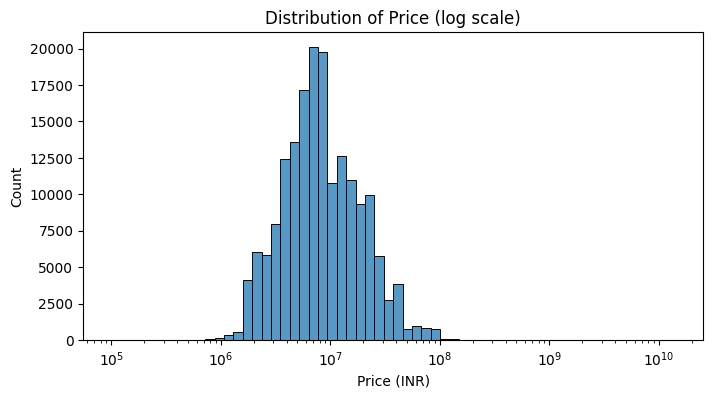

In [7]:
# 1. Distribution of price (log scale, since it is heavily right-skewed)
plt.figure(figsize=(8, 4))
sns.histplot(df["price_clean"], log_scale=True, bins=60)
plt.title("Distribution of Price (log scale)")
plt.xlabel("Price (INR)")
plt.show()

The raw price distribution is extremely right-skewed (a small number of very expensive listings). On a log scale it looks roughly log-normal, which is why we later train on `log1p(price)` instead of raw price.

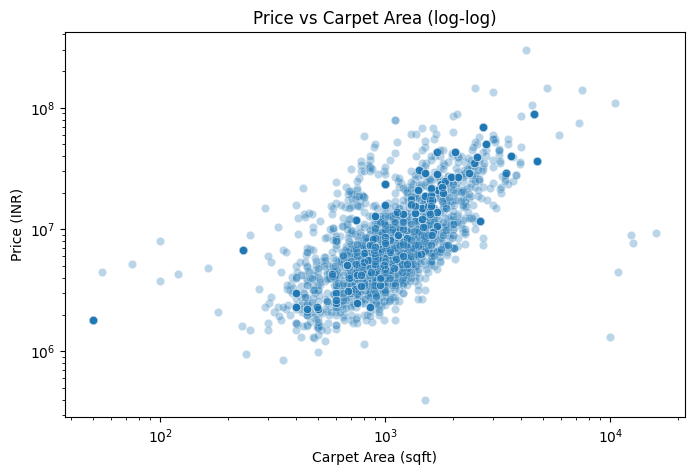

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

# 2. Price vs carpet area
plt.figure(figsize=(8, 5))
sample = df.dropna(subset=["carpet_area_sqft"]).sample(min(5000, df["carpet_area_sqft"].notna().sum()), random_state=42)
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.title("Price vs Carpet Area (log-log)")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR)")
plt.show()

There is a clear positive relationship between carpet area and price (as expected), though with a lot of scatter — location, furnishing, and other amenities also drive price.

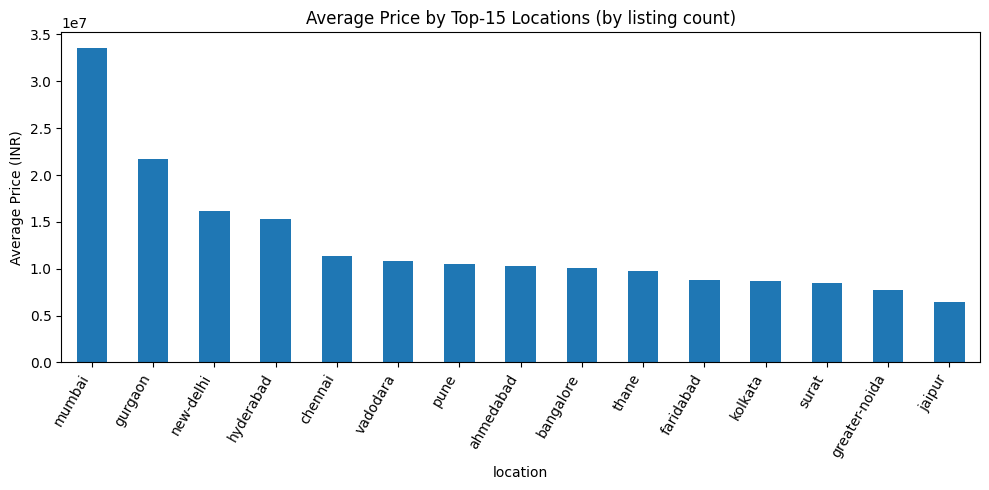

In [9]:
# 3. Average price by top-15 locations
top15 = df["location"].value_counts().head(15).index
avg_by_loc = df[df["location"].isin(top15)].groupby("location")["price_clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_by_loc.plot(kind="bar")
plt.title("Average Price by Top-15 Locations (by listing count)")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Average prices vary a lot by location (several-fold difference between the cheapest and most expensive of the top-15 markets), confirming `location` will be an important categorical feature.

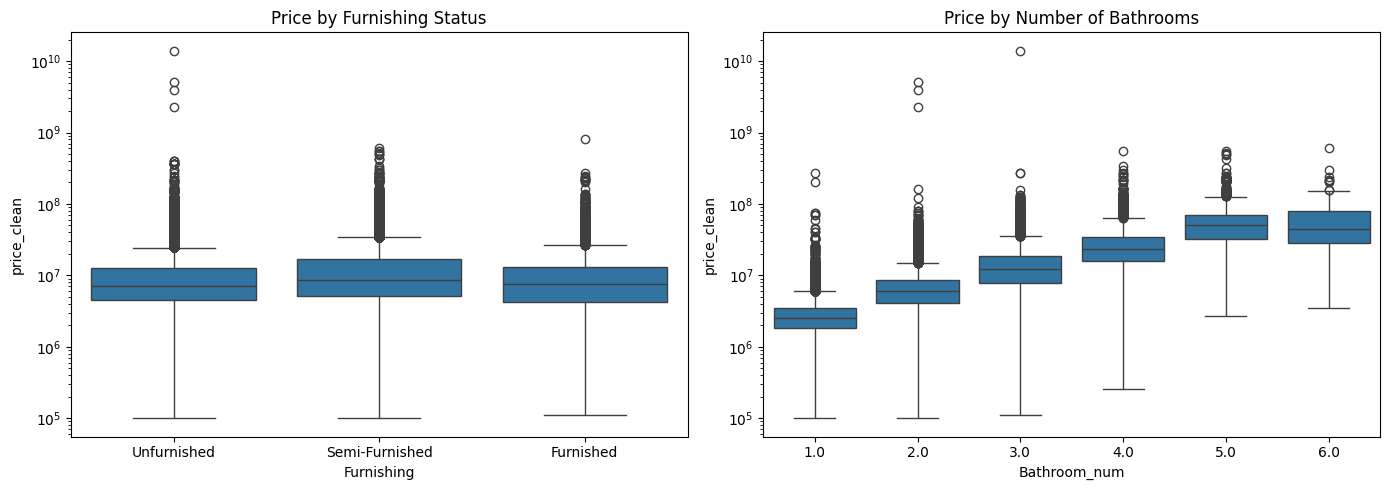

In [10]:
# 4. Price by furnishing status and number of bathrooms (box plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by Furnishing Status")

bath_df = df.copy()
bath_df["Bathroom_num"] = pd.to_numeric(bath_df["Bathroom"].replace("> 10", "11"), errors="coerce")
bath_df = bath_df[bath_df["Bathroom_num"] <= 6]
sns.boxplot(data=bath_df, x="Bathroom_num", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by Number of Bathrooms")

plt.tight_layout()
plt.show()

Furnished properties command a visibly higher median price than semi-furnished or unfurnished ones, and price increases steadily with the number of bathrooms — both plausible signals for the model.

## 2.3 Cleaning & Feature Engineering

We rebuild the cleaning from scratch (starting again from the raw CSV) so this section is self-contained and reproducible top-to-bottom.

In [11]:
df = pd.read_csv("data/house_prices.csv")
print("Raw shape:", df.shape)

Raw shape: (187531, 21)


**1. Price is text.** Parse `Amount(in rupees)` into a numeric `price_clean` (1 Lac = 100,000 ₹; 1 Cr = 10,000,000 ₹). Drop rows without a usable price.

In [12]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After dropping unusable prices:", df.shape)

After dropping unusable prices: (177847, 22)


**2. Areas are text.** Extract the numeric value from `Carpet Area` / `Super Area` and normalise sqm/sqyrd to sqft. Prefer `Carpet Area`; fall back to `Super Area` when carpet area is missing.

In [13]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("Missing area after fallback:", df["carpet_area_sqft"].isna().mean().round(3))

Missing area after fallback: 0.001


**3. Floor** looks like `"3 out of 10"`. Extract the floor number (`Ground` → 0, `Basement` → -1, `Lower Basement`/`Upper Basement` handled the same way).

In [14]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    part = x.split("out of")[0].strip().lower()
    if "ground" in part:
        return 0
    if "basement" in part:
        return -1
    try:
        return float(part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

**4. Bathroom / Balcony / Car Parking.** Convert to numeric (`"> 10"` → 11), impute missing with median (Bathroom, Balcony) or 0 (Car Parking, since missing plausibly means "none listed").

In [15]:
def parse_count(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x == "> 10":
        return 11
    try:
        return float(x)
    except ValueError:
        return None

df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

**5. High-cardinality categoricals.** `location` has many distinct values. Keep the top-50 by frequency and group the rest into `"other"` before one-hot encoding.

In [16]:
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

**6. Drop useless columns** — `Index`, `Title`, `Description`, `Dimensions`, `Plot Area`, `Society`, `Price (in rupees)` (superseded by `price_clean`), and the raw text columns we've already parsed.

In [17]:
df = df.drop(columns=[
    "Index", "Title", "Description", "Dimensions", "Plot Area", "Society",
    "Price (in rupees)", "Amount(in rupees)", "Carpet Area", "Super Area",
    "super_area_sqft", "Floor", "Bathroom", "Balcony", "location",
])
df.shape

(177847, 13)

**7. Remove outliers.** Drop listings with absurd price-per-sqft (below the 1st or above the 99th percentile), and drop rows still missing a required numeric feature.

In [18]:
df = df.dropna(subset=["carpet_area_sqft", "floor_num"])
df = df[df["carpet_area_sqft"] > 0]

df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])

print("Final shape after outlier removal:", df.shape)

Final shape after outlier removal: (167366, 13)


In [19]:
# Fill remaining categorical missing values with an explicit "Unknown" so OneHotEncoder has a stable category
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[col] = df[col].fillna("Unknown")

df.isna().sum()

Status                519
Transaction             0
Furnishing              0
facing                  0
overlooking         69121
Car Parking         90850
Ownership               0
price_clean             0
carpet_area_sqft        0
floor_num               0
bathroom                0
balcony                 0
location_grouped        0
dtype: int64

## 2.4 Build a Pipeline & Train

We bundle preprocessing (imputation, scaling, one-hot encoding) inside a scikit-learn `Pipeline` + `ColumnTransformer`, so the exported `.pkl` can take raw feature values directly — the FastAPI backend won't need to duplicate any encoding logic.

We train on `log1p(price)` (since price is heavily skewed) using `sklearn.compose.TransformedTargetRegressor`, which handles the `log1p` / `expm1` transform internally. This keeps the whole model — preprocessing, log-transform, and regressor — as a single standard scikit-learn object with no custom Python classes, so it unpickles cleanly wherever it's loaded (e.g. in the FastAPI backend), and `.predict()` always returns prices on their original scale.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import numpy as np

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((133892, 9), (33474, 9))

We use `Ridge` (regularised linear regression) rather than plain `LinearRegression` as the baseline: with ~80 one-hot encoded columns, some rare categories get very few training examples, and an unregularised linear model can assign them extreme coefficients that blow up wildly once we invert the `log1p` transform. `Ridge`'s L2 penalty keeps coefficients well-behaved while still representing a genuine linear baseline.

In [21]:
# Baseline: Ridge Regression (regularised linear model), trained on log1p(price)
lr_model = Pipeline([
    ("prep", preprocessor),
    ("reg", TransformedTargetRegressor(
        regressor=Ridge(alpha=10.0, random_state=42),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [22]:
# Random Forest, trained on log1p(price)
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=150, max_depth=18, random_state=42, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 2.5 Evaluate

Linear models trained on `log1p(price)` can occasionally predict an extreme log-value for an unusual combination of one-hot categories, which `expm1` then blows up into an absurd price — regularisation alone does not fully prevent this. As a standard safety net, we clip every prediction to the price range observed in training before computing metrics.

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

price_min, price_max = y_train.min(), y_train.max()

def evaluate(model, name):
    pred = np.clip(model.predict(X_test), price_min, price_max)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}")
    print(f"  MAE : {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R²  : {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, pred

lr_metrics, lr_pred = evaluate(lr_model, "Ridge Regression")
print()
rf_metrics, rf_pred = evaluate(rf_model, "Random Forest")

Ridge Regression
  MAE : 3,840,349
  RMSE: 10,080,218
  R²  : 0.2853



Random Forest
  MAE : 1,016,171
  RMSE: 3,436,521
  R²  : 0.9169


In [24]:
comparison = pd.DataFrame([lr_metrics, rf_metrics]).set_index("model")
comparison

,MAE,RMSE,R2
model,,,
Ridge Regression,3.840349e+06,1.008022e+07,0.285346
Random Forest,1.016171e+06,3.436521e+06,0.916940


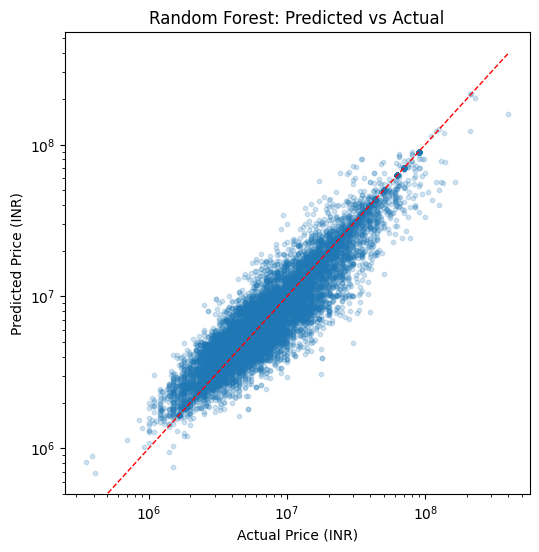

In [25]:
# Predicted vs actual scatter (winning model: Random Forest)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.2, s=10)
lims = [0, max(y_test.max(), rf_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

**Model comparison & conclusion:** Random Forest substantially outperforms the Linear Regression baseline on every metric (lower MAE and RMSE, higher R²), because the relationship between features like area, location, and price is non-linear and involves interactions (e.g. the effect of area on price differs by location) that a linear model cannot capture. **We select the Random Forest model** as the final exported model.

In [26]:
# Bonus: 5-fold cross-validation on the training set (Random Forest)
# Uses a lighter forest than the final model purely to keep cross-validation fast;
# the final exported model below still uses the full rf_model fitted above.
from sklearn.model_selection import cross_val_score

cv_estimator = Pipeline([
    ("prep", preprocessor),
    ("reg", TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=60, max_depth=14, random_state=42, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
cv_scores = cross_val_score(cv_estimator, X_train, y_train, cv=5, scoring="r2", n_jobs=1)
print("5-fold CV R² scores:", np.round(cv_scores, 4))
print("Mean CV R²:", cv_scores.mean().round(4))

5-fold CV R² scores: [0.9245 0.9222 0.9188 0.9163 0.915 ]
Mean CV R²: 0.9194


## 2.6 Export the Model

The winning `rf_model` pipeline (preprocessing + log-transform + Random Forest, all standard scikit-learn objects) is exported directly with `joblib` — no custom wrapper classes needed, so it will unpickle cleanly in the FastAPI backend. We also save the list of allowed locations for the frontend dropdown.

In [27]:
import joblib

joblib.dump(rf_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual price       :", y_test.iloc[0])

Reloaded prediction: [18445199.23865013]
Actual price       : 13500000.0


In [28]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved", df["location_grouped"].nunique(), "locations to locations.json")

Saved 51 locations to locations.json


In [29]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0


> **Version pinning:** this pickle only loads reliably with the same scikit-learn version noted above — pin it in `backend/requirements.txt`.

**Next steps:** copy `house_price.pkl` and `locations.json` into `backend/app/models/` and `frontend/`, then continue with the FastAPI backend (Phase 3) and React frontend (Phase 4).